### Mar 11 quadratic zeeman

In [2]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [57]:
"""
1.5 - mar 20 - 172.7mV
2.5 - mar 20 - 299.41mV
2.5 - mar 16 - 304.5mV - don't use
3.6 - mar 20 - 436.2mV
3.6 - mar 16 - 457.8mV - don't use
4.45- mar 11 - 534mV
5.9 - mar 23 - 735.27mV
6.9 - mar 23 - 852mV
7.0 - mar 20 - 857.4mV
7.2 - mar 13 - 885mV
8.65- mar 16 - 1070mV
8.83- mar 23 - 1094mV
8.93- mar 20 - 1106mV

9.02- apr 1  - 1116mV
7.75- apr 1  - 960
6.9 - apr 1  - 856.7
5.3 - apr 1  - 659.7
4.45- apr 1  - 543.0mV
4.3 - apr 1  - 540.8
2.9 - apr 1  - 362
1.75- apr 1  - 207.6
"""

freq = 1.5
date = "Mar 20"
vHoriz = 172  # mV
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_5s_" + str(vHoriz).replace('.', 'p') + ".csv")
# time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_" + str(vHoriz).replace('.', 'p') + "mV.csv")
# time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_10s.csv")
vHoriz = (vHoriz+0.7) / 1000
vShift = ufloat(vHoriz,0.0001)
vShift = vShift - 0.09/1000 # Vshift in V

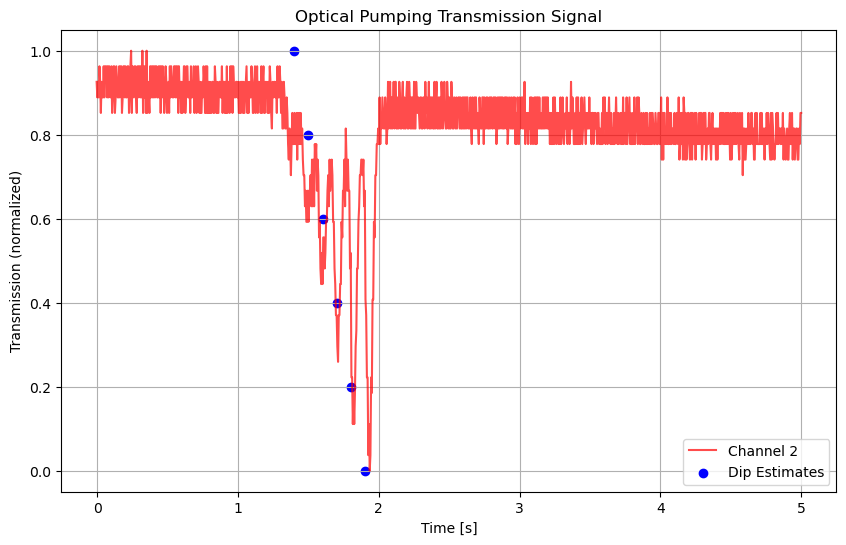

In [59]:
t0 = 0.5
tf = 5.5
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([1.4,1.5,1.6,1.7,1.8,1.9])

m.plot_quadraticZeeman_sextuple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

A 0.9320220640054814
m -0.029058391487139932
h1 0.11289078598312705
g1 0.0176787133962497
x0_1 1.372348021578382
h2 0.24195650568799276
g2 0.030573495892042495
x0_2 1.4919734524973796
h3 0.3677251439027665
g3 0.029583220742498716
x0_3 1.5998095918804134
h4 0.5485880150996363
g4 0.023339647434138598
x0_4 1.7080341857494252
h5 0.7415017663422089
g5 0.020062717869509188
x0_5 1.8212807500954897
h6 0.8624044792620134
g6 0.02184981104706431
x0_6 1.933701540280866


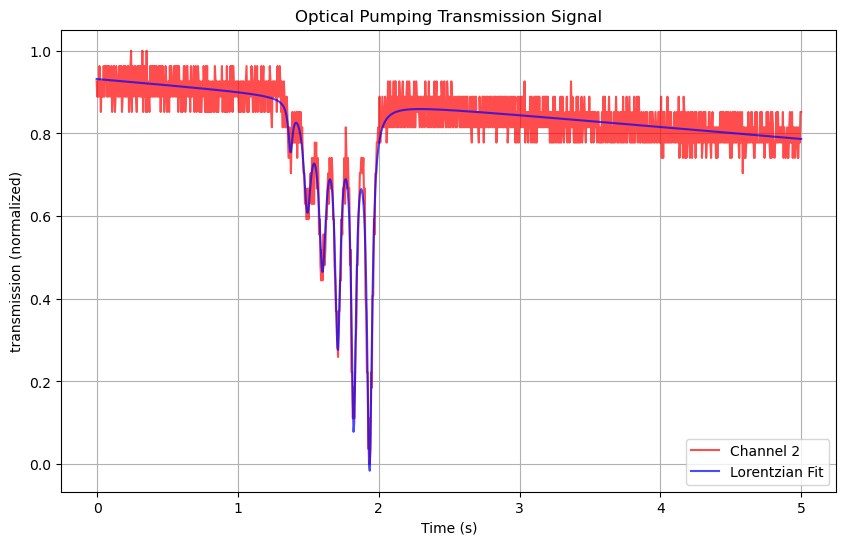

In [60]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4",  "h5", "g5", "x0_5",  "h6", "g6", "x0_6"]
p0 = (1, -0.02, 0.2, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3], 0.5, 0.1, x0s[4], 0.5, 0.1, x0s[5])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.sextuple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)


In [61]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0
x0_5_u = ufloat(popt[16], perr[16]) + t0
x0_6_u = ufloat(popt[19], perr[19]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)
x0_5_index = int(x0_5_u.n // dt)
x0_6_index = int(x0_6_u.n // dt)

numAvg = 10


# Values in array below are from 175kHz, 150, 100, 50, 25, 75, 125 from Mar 23rd measurements
# These are with a "0" Vhoriz of 0.09mV
# V0s = np.array([2.924, 2.91, 2.939, 2.925, 2.899, 2.925, 2.914, 2.91]) / 10
# uV0s = np.array([0.071, 0.063, 0.046, 0.043, 0.042, 0.043, 0.054, 0.056]) / 10

# values are from 15,20,25,30,40,60,70,80,90,110,150,195 on April 1st
V0s = np.array([2.922,2.916,2.925,2.926,2.94,2.949,2.943,2.957,2.898,2.984,2.960]) / 10
uV0s = np.array([0.043,0.033,0.036,0.045,0.042,0.047,0.05,0.047,0.051,0.059,0.073]) / 10



weights = 1 / uV0s**2
v_0Field = ufloat(np.sum(weights * V0s) / np.sum(weights),np.sqrt(1 / np.sum(weights))) # New from Mar 29

# v_0Field = ufloat(0.30,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]))
v_5 = ufloat(np.mean(y1[x0_5_index - numAvg : x0_5_index + numAvg]),
             np.std(y1[x0_5_index - numAvg : x0_5_index + numAvg]))
v_6 = ufloat(np.mean(y1[x0_6_index - numAvg : x0_6_index + numAvg]),
             np.std(y1[x0_6_index - numAvg : x0_6_index + numAvg]))


# print(y1[x0_5_index - numAvg : x0_5_index + numAvg])
# print(y1[x0_6_index - numAvg : x0_6_index + numAvg])

# VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100) * 1.03360784475
# VtoBHoriz = ufloat(1.705174,0.028108) / 1000
# VtoBSweep = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd
VtoBSweep = ufloat(6.19773,0.04316)*10**(-5) # new VtoB from Apr 1

# VtoBHoriz = ufloat(1.730183,0.033567) / 1000 # from mar23
# VtoBHoriz = VtoBSweep * ufloat(27.731,0.047) # new from Mar25
# VtoBHoriz = ufloat(1.7326589,0.0112084) / 10**3 # new from Mar27 (Using exclusively new data, shifting it b 0.09mV, and using 0 intercept)
# VtoBHoriz = ufloat(1.7619711,0.0106221) / 10**3 # new from Mar27
# VtoBHoriz = ufloat(1.715,0.010) / 10**3 # fake from Mar28
# VtoBHoriz = ufloat(1.7180739,0.0101949) / 10**3 # from Mar28
# VtoBHoriz = ufloat(1.7352854,0.0104721)/10**3 # From Mar30 many additional points for calibration
VtoBHoriz = ufloat(1.7327119,0.0124991) / 10**3 # From Apr1

print(f"v_0Field: {v_0Field:.2ue}")
print(f"VtoBHoriz: {VtoBHoriz:.2ue}")


dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip5 = (v_5-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip6 = (v_6-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")
print(f"B field of dip 5: {dip5:.3e}")
print(f"B field of dip 6: {dip6:.3e}")

v_0Field: (2.933+/-0.014)e-01
VtoBHoriz: (1.733+/-0.012)e-03
B field of dip 1: (3.210+/-0.022)e-04
B field of dip 2: (3.212+/-0.022)e-04
B field of dip 3: (3.215+/-0.022)e-04
B field of dip 4: (3.220+/-0.022)e-04
B field of dip 5: (3.223+/-0.022)e-04
B field of dip 6: (3.226+/-0.022)e-04


In [62]:

filepath = 'models/quadraticRb85ZeemanData.csv'

m.append_to_sextupleZeeman_csv(freq, (dip1,dip2,dip3,dip4,dip5,dip6), filepath)

In [8]:
"""
2.5 - mar 20 - 197.89mV
3.6 - mar 20 - 286.74mV
3.7 - mar 16 - 302mV
5.5 - mar 16 - 457.8mV
6.7 - mar 11 - 534mV
7.0 - mar 20 - 578mV
8.8 - mar 23 - 731.2mV
10.3- mar 23 - 854.9mV
10.8- mar 13 - 879mV
13.1- mar 16 - 1070mV
13.4- mar 20 - 1100mV
13.6- mar 23 - 1111mV
6p7 - apr 1  - 544.0mV
"""

freq = 8.8
date = "Mar 23"
vHoriz = 731.2 # V
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_" + str(vHoriz).replace('.', 'p') + "mV.csv")
vHoriz = vHoriz / 1000

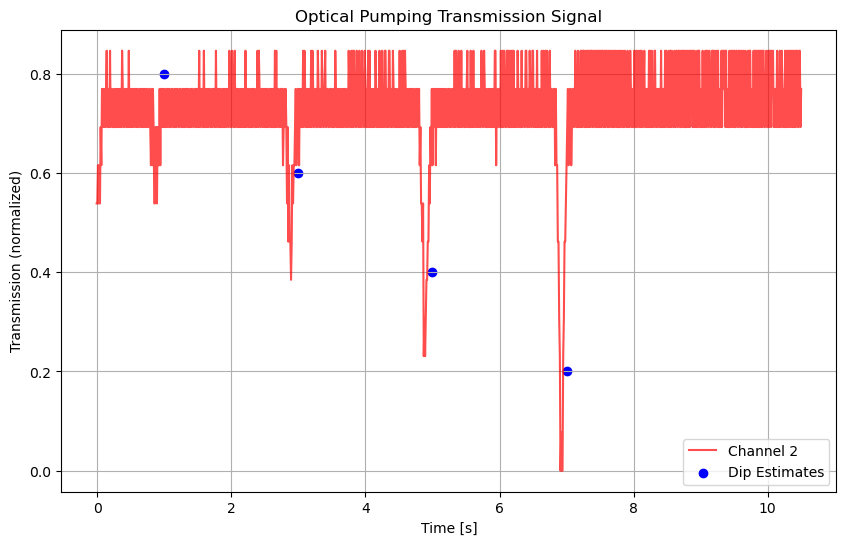

In [9]:
t0 = 0.5
tf = 11
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([1,3,5,7])

m.plot_quadraticZeeman_quadruple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [10]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4"]
p0 = (1, -0.02, 1, 0.1, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,10,2,2,10,2,2,10,2,2,10)

# print(len(p0))
# print(len(variables))
# print(len(lower_bound))
# print(len(upper_bound))

bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.quadruple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.7511597320603494
m -7.86989081940915e-37
h1 0.12724092595557854
g1 0.06788457669763982
x0_1 0.872718947423853
h2 0.31993291809248614
g2 0.03782689278160552
x0_2 2.8847951310674715
h3 0.50404643321259
g3 0.04095503618624537
x0_3 4.891348050032465
h4 0.8007054086201508
g4 0.034251080821162655
x0_4 6.9257631278043865


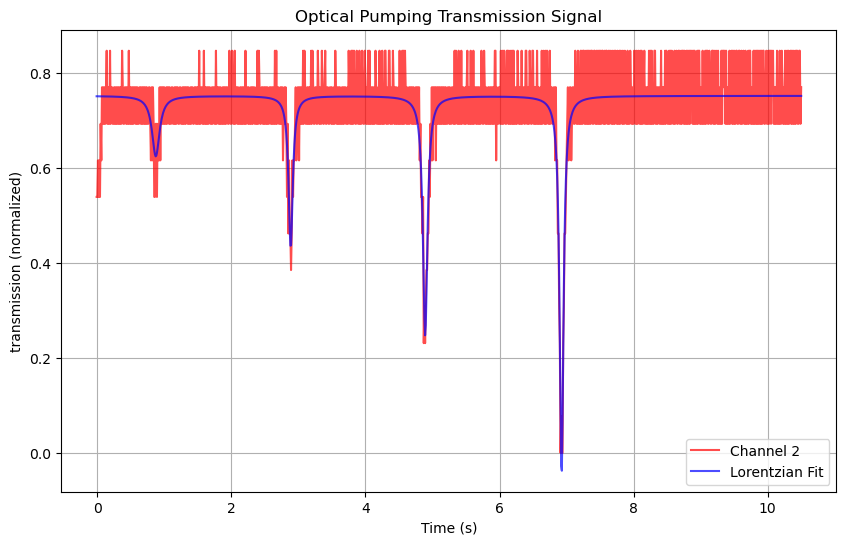

In [11]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.quadruple_lorentz, "fit to " + savename)


In [13]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)

numAvg = 10

vShift = ufloat(vHoriz,0.00001) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

V0s = np.array([2.924, 2.91, 2.939, 2.925, 2.899, 2.925, 2.914, 2.91]) / 10
uV0s = np.array([0.071, 0.063, 0.046, 0.043, 0.042, 0.043, 0.054, 0.056]) / 10
weights = 1 / uV0s**2
V_0Field = ufloat(np.sum(weights * V0s) / np.sum(weights),np.sqrt(1 / np.sum(weights))) # New from Mar 29

# v_0Field = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]))

# VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100) * 1.03360784475
# VtoBHoriz = ufloat(1.705174,0.028108) / 1000
# VtoBSweep = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd
VtoBSweep = ufloat(6.19773,0.04316)*10**(-5) # new VtoB from Apr 1

# VtoBHoriz = ufloat(1.730183,0.033567) / 1000 # from mar23
# VtoBHoriz = VtoBSweep * ufloat(27.731,0.047) # new from Mar25
# VtoBHoriz = ufloat(1.7326589,0.0112084) / 10**3 # new from Mar27
# VtoBHoriz = ufloat(1.7619711,0.0106221) / 10**3 # new from Mar27
# VtoBHoriz = ufloat(1.7176050,0.0525303) / 10**3 # from Mar28
# VtoBHoriz = ufloat(1.7180739,0.0101949) / 10**3 # from Mar28
# VtoBHoriz = ufloat(1.7352854,0.0104721)/10*83 # From Mar30 many additional points for calibration
VtoBHoriz = ufloat(1.7327119,0.0124991) / 10**3 # From Apr1

print(f"V_0Field: {V_0Field:.2ue}")
print(f"VtoBHoriz: {VtoBHoriz:.2ue}")

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")

VtoBHoriz: (1.721+/-0.010)e-03
B field of dip 1: (1.254+/-0.008)e-03
B field of dip 2: (1.257+/-0.008)e-03
B field of dip 3: (1.260+/-0.008)e-03
B field of dip 4: (1.263+/-0.008)e-03


In [79]:
filepath = 'models/quadraticRb87ZeemanData.csv'

m.append_to_quadrupleZeeman_csv(freq, (dip1,dip2,dip3,dip4), filepath)